In [1]:
import matplotlib.pyplot as plt
from datetime import datetime
date_str = datetime.now().strftime('%m%d')
import numpy as np

import brainpy as bp
import brainpy.math as bm

import tqdm

from network import DecisionMakingNet
from tools import Tool
from motor import process_motor_readout, plot_final_results_separate

/opt/miniconda3/envs/brainpy_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/opt/miniconda3/envs/brainpy_env/lib/python3.10/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=int32 to dtype=uint32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(
/opt/miniconda3/envs/brainpy_env/lib/python3.10/site-packages/brainpy/mixin.py:477: UserWarning: Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.
  warnings.warn('Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.', UserWarning)
Running for 1,750,000 iterations: 100%|██████████| 1750000/1750000 [01:59<00:00, 14590.28it/s]


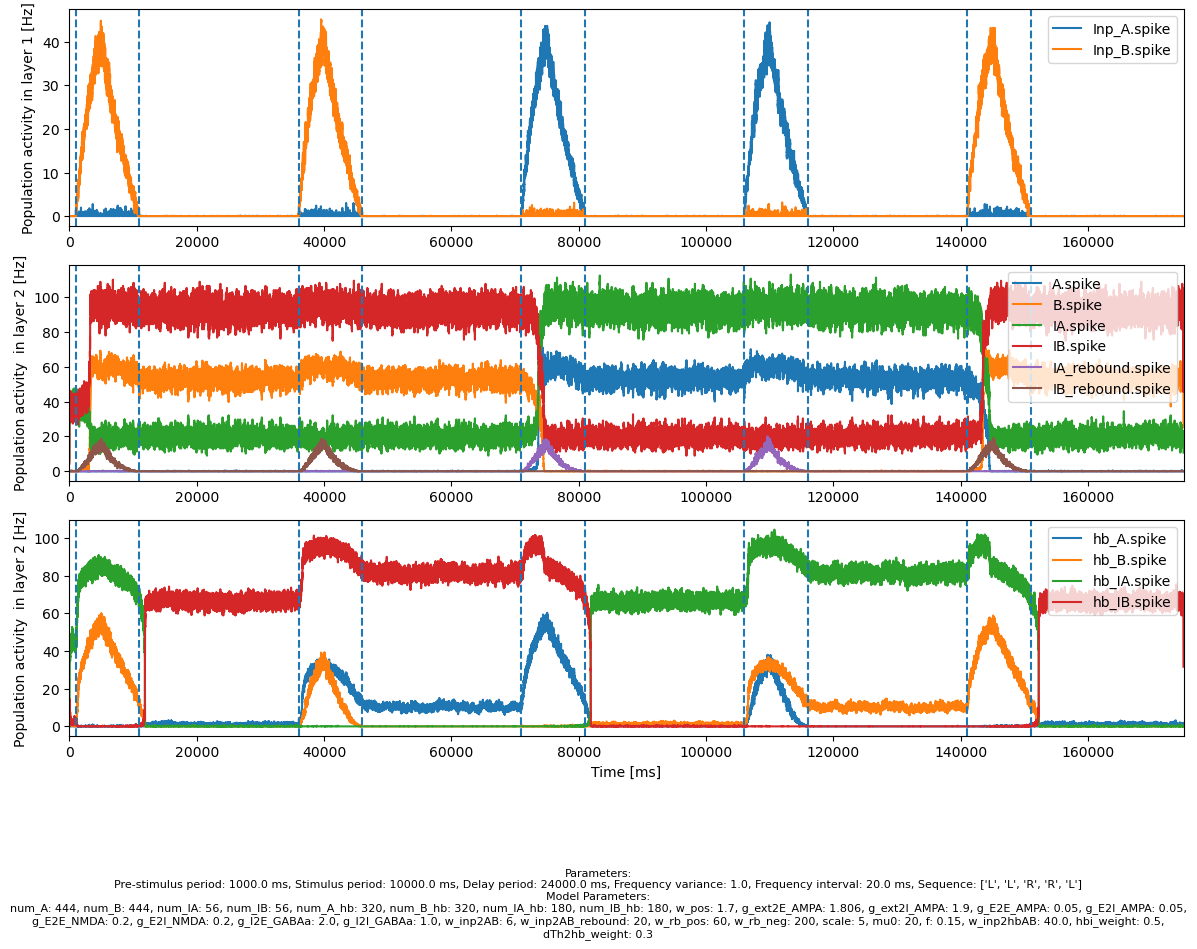

In [2]:
params = {
    'num_A': 888 // 2,
    'num_B': 888 // 2,
    'num_IA': 112 // 2,
    'num_IB': 112 // 2,
    'num_A_hb': 640 // 2,
    'num_B_hb': 640 // 2,
    'num_IA_hb': 360 // 2,
    'num_IB_hb': 360 // 2,
    'w_pos': 1.7, 
    'g_ext2E_AMPA': 1.806,
    'g_ext2I_AMPA': 1.9,
    'g_E2E_AMPA': 0.05,
    'g_E2I_AMPA': 0.05,
    'g_E2E_NMDA': 0.2,
    'g_E2I_NMDA': 0.2,
    'g_I2E_GABAa': 2.0,
    'g_I2I_GABAa': 1.0,
    'w_inp2AB': 6, 
    'w_inp2AB_rebound': 20,
    'w_rb_pos': 60,
    'w_rb_neg': 200,
    'scale': 5,
    'mu0': 20,
    'f': 0.15,
    'w_inp2hbAB': 40.,
    'hbi_weight': 0.5,
    'dTh2hb_weight': 0.3,
}
# define tectum stimulus sequence
seqs = ['L', 'L', 'R', 'R', 'L']
# build model
bm.set_dt(0.1)
net = DecisionMakingNet(params=params, scale=params['scale'])
tool = Tool(seq=seqs)

# define input
def give_input():
    i = bp.share['i']
    net.Inp_A.freqs[0] = IA_freqs[i]
    net.Inp_B.freqs[0] = IB_freqs[i]
    
mu0 = params['mu0']
coherence = 100.
IA_freqs = tool.generate_freqs(R=mu0 + mu0 / 100. * coherence, L=mu0 - mu0 / 100. * coherence)
IB_freqs = tool.generate_freqs(R=mu0 - mu0 / 100. * coherence, L=mu0 + mu0 / 100. * coherence)


# simulation
monlist = [ 'Inp_A.spike', 'Inp_B.spike', 'A.spike', 'B.spike', 'IA.spike', 'IB.spike',
            'IA_rebound.spike', 'IB_rebound.spike', 'hb_A.spike', 'hb_B.spike', 'hb_IA.spike', 'hb_IB.spike']
runner = bp.DSRunner(net, inputs=give_input, monitors=monlist)
runner.run(tool.total_period)


# visualization
pltlist = ['Inp_A', 'Inp_B', 'A', 'B', 'IA', 'IB', 'IA_rebound', 'IB_rebound',
           'hb_A', 'hb_B', 'hb_IA', 'hb_IB']
tool.visualize_results(runner.mon, monlist, params, t_start=0., title='Decision Making Network', index=0, savefig=True, filename=f'../figures/{date_str}_decision_making_network_long1.pdf')

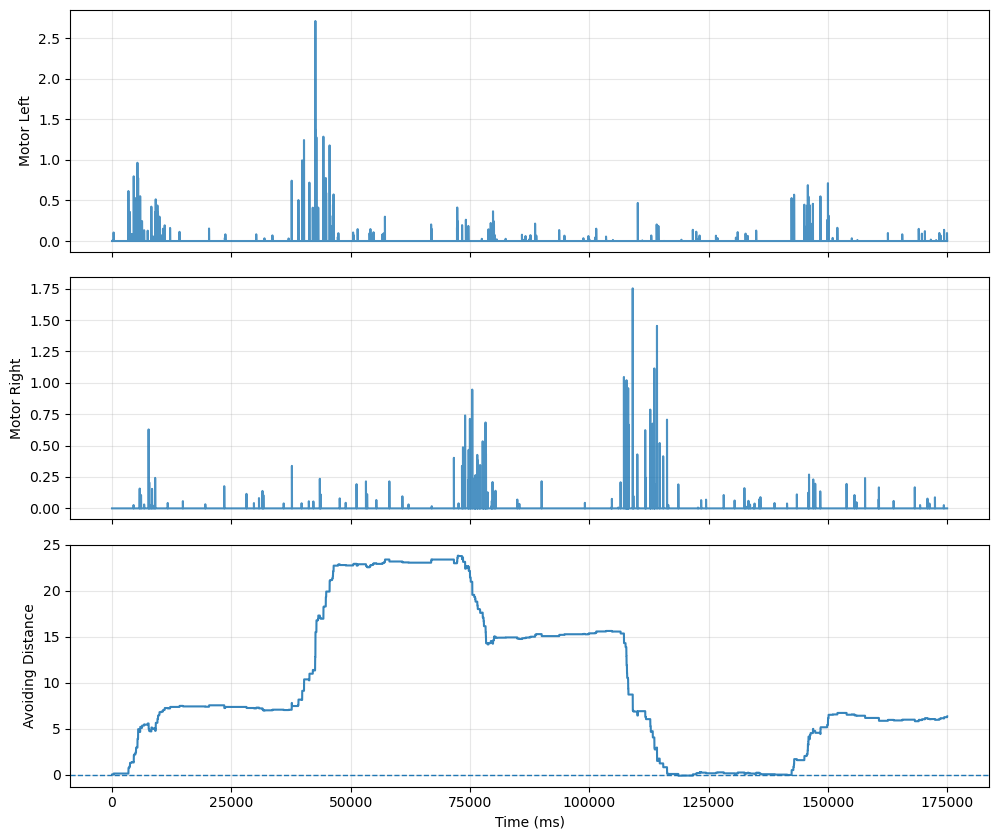

In [3]:
# generate motor output
ts, mA, mB = process_motor_readout(runner)
plot_final_results_separate(ts, mA, mB, savepath=f"../figures/{date_str}SFig8A_example_motor.pdf", show=True)